In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

orders    = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
items     = pd.read_csv('olist_order_items_dataset.csv')
payments  = pd.read_csv('olist_order_payments_dataset.csv')

print("orders:",    orders.shape)
print("customers:", customers.shape)
print("items:",     items.shape)
print("payments:",  payments.shape)

orders: (99441, 8)
customers: (99441, 5)
items: (112650, 7)
payments: (103886, 5)


In [26]:
# merge orders with customers
df = orders.merge(customers[['customer_id','customer_unique_id']],
                  on='customer_id', how='left')

# delivered orders only
df = df[df['order_status'] == 'delivered'].copy()
df['order_purchase_timestamp'] = pd.to_datetime(
    df['order_purchase_timestamp'])

# extract order month
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

# each customer's first order month = their cohort
df['cohort'] = df.groupby('customer_unique_id')['order_month'] \
                  .transform('min')

# months since first order
df['months_since_first'] = (
    df['order_month'] - df['cohort']
).apply(lambda x: x.n)

# count unique customers per cohort + months_since_first
cohort_data = (
    df.groupby(['cohort','months_since_first'])['customer_unique_id']
      .nunique()
      .reset_index()
      .rename(columns={'customer_unique_id':'customers'})
)

# pivot into retention matrix
cohort_pivot = cohort_data.pivot_table(
    index='cohort',
    columns='months_since_first',
    values='customers'
)

# convert to retention %
cohort_size = cohort_pivot[0]
retention = cohort_pivot.divide(cohort_size, axis=0).round(3) * 100

print(retention.iloc[:12, :7])

months_since_first      0      1    2    3    4    5    6
cohort                                                   
2016-09             100.0    NaN  NaN  NaN  NaN  NaN  NaN
2016-10             100.0    NaN  NaN  NaN  NaN  NaN  0.4
2016-12             100.0  100.0  NaN  NaN  NaN  NaN  NaN
2017-01             100.0    0.3  0.3  0.1  0.4  0.1  0.4
2017-02             100.0    0.2  0.3  0.1  0.4  0.1  0.2
2017-03             100.0    0.4  0.4  0.4  0.4  0.2  0.2
2017-04             100.0    0.6  0.2  0.2  0.3  0.3  0.4
2017-05             100.0    0.5  0.5  0.3  0.3  0.3  0.4
2017-06             100.0    0.5  0.4  0.4  0.3  0.4  0.4
2017-07             100.0    0.5  0.3  0.2  0.3  0.2  0.3
2017-08             100.0    0.7  0.3  0.3  0.3  0.5  0.3
2017-09             100.0    0.7  0.5  0.3  0.4  0.2  0.2


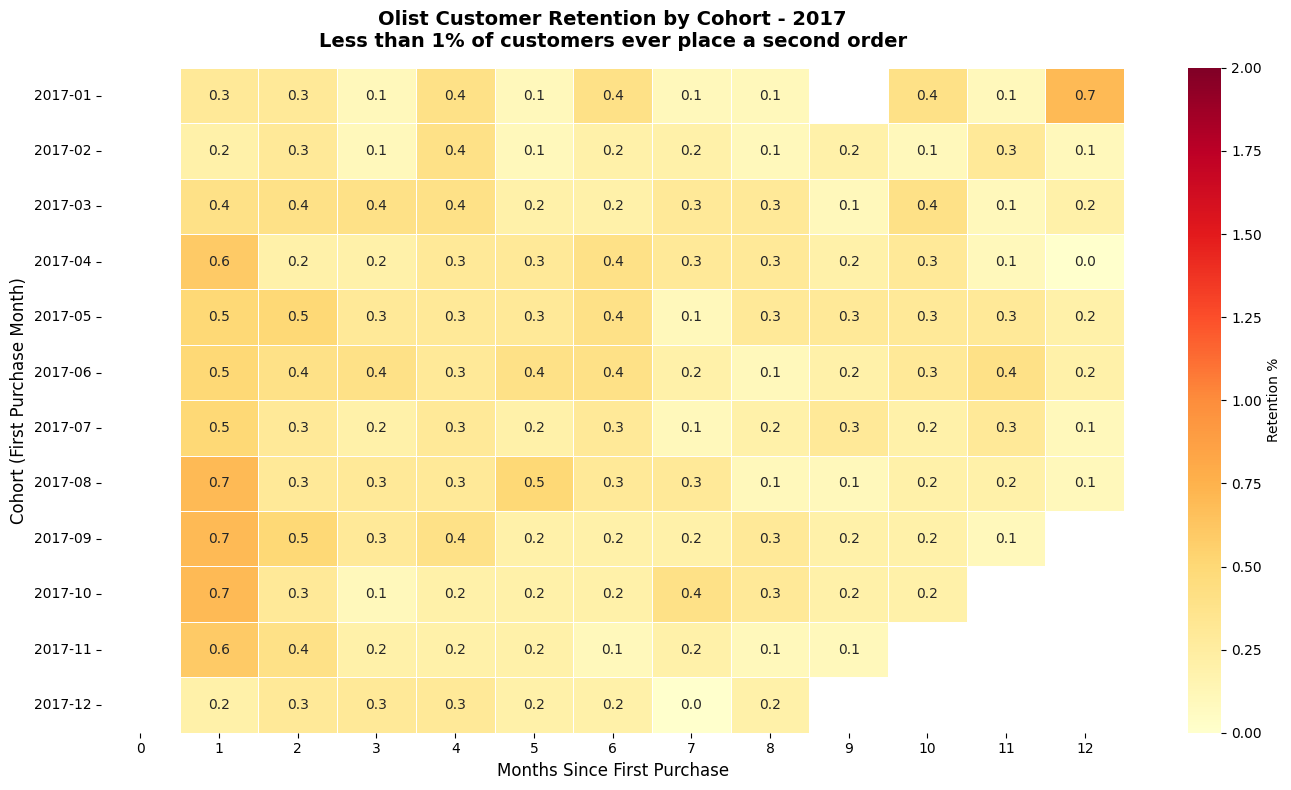

saved: cohort_retention_heatmap.png


In [35]:
retention_plot = retention[
    (retention.index >= '2017-01') &
    (retention.index <= '2017-12')
].iloc[:, :13]



plot_data = retention_plot.copy()
plot_data[0] = np.nan

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    plot_data,
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label':'Retention %'},
    vmin=0, vmax=2
)
ax.set_title(
    'Olist Customer Retention by Cohort - 2017\n'
    'Less than 1% of customers ever place a second order',
    fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Months Since First Purchase', fontsize=12)
ax.set_ylabel('Cohort (First Purchase Month)', fontsize=12)
ax.set_yticklabels(
    [str(c) for c in retention_plot.index], rotation=0)

plt.tight_layout()
plt.savefig('cohort_retention_heatmap.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("saved: cohort_retention_heatmap.png")

In [28]:
# merge payments onto orders
order_payments = payments.groupby('order_id')['payment_value'] \
                          .sum().reset_index()
order_payments.columns = ['order_id','total_payment']



revenue_df = df.merge(order_payments, on='order_id', how='left')

# revenue per cohort
cohort_revenue = (
    revenue_df.groupby('cohort')
    .agg(
        total_customers = ('customer_unique_id','nunique'),
        total_revenue   = ('total_payment','sum'),
        avg_order_value = ('total_payment','mean')
    )
    .reset_index()
)



cohort_revenue = cohort_revenue[
    (cohort_revenue['cohort'] >= '2017-01') &
    (cohort_revenue['cohort'] <= '2017-12')
].copy()

cohort_revenue['cohort'] = cohort_revenue['cohort'].astype(str)
cohort_revenue['revenue_per_customer'] = (
    cohort_revenue['total_revenue'] /
    cohort_revenue['total_customers']
).round(2)

print(cohort_revenue[[
    'cohort','total_customers',
    'total_revenue','revenue_per_customer'
]].to_string(index=False))

 cohort  total_customers  total_revenue  revenue_per_customer
2017-01              717      130978.52                182.68
2017-02             1628      277851.71                170.67
2017-03             2503      428986.89                171.39
2017-04             2256      403225.15                178.73
2017-05             3451      583525.72                169.09
2017-06             3037      504693.73                166.18
2017-07             3752      577217.22                153.84
2017-08             4057      659206.97                162.49
2017-09             4004      709029.57                177.08
2017-10             4328      755985.35                174.67
2017-11             7060     1158152.81                164.04
2017-12             5338      837937.62                156.98


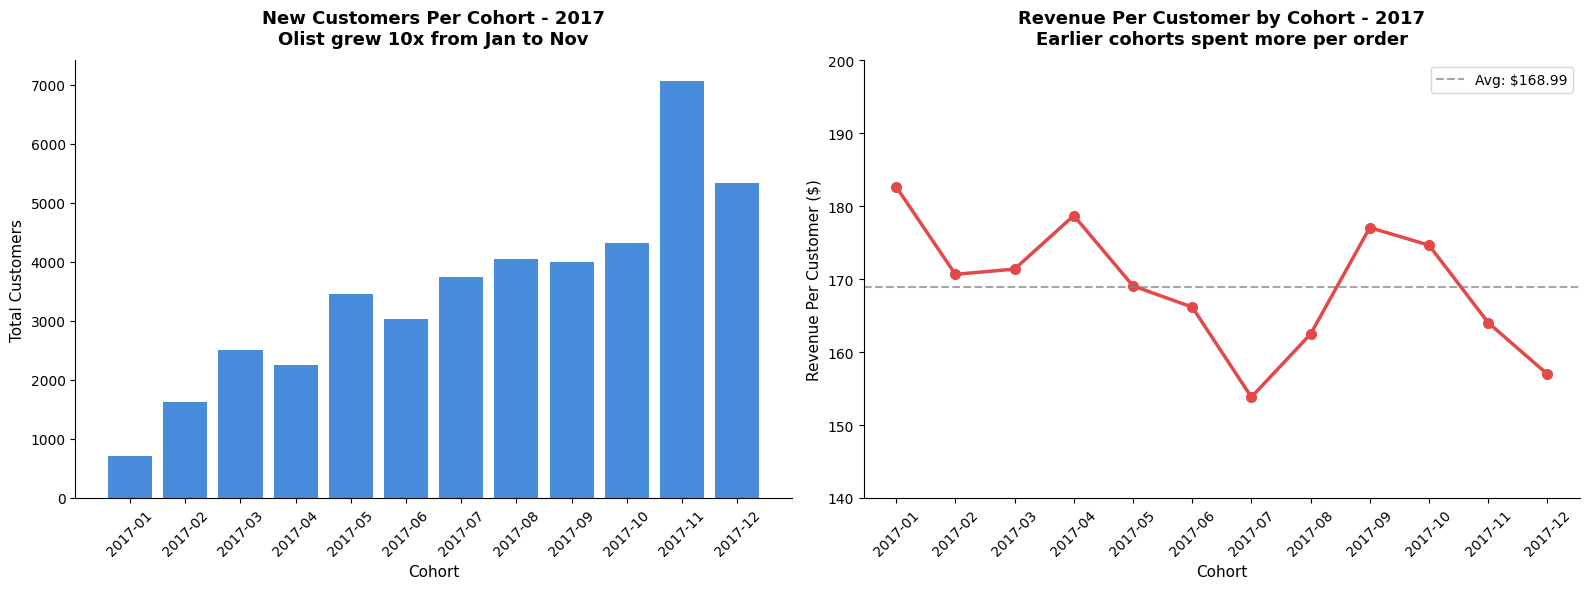

saved: cohort_revenue.png


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: customers per cohort
axes[0].bar(cohort_revenue['cohort'],
            cohort_revenue['total_customers'],
            color='#2a78d6', alpha=0.85)
axes[0].set_title(
    'New Customers Per Cohort - 2017\nOlist grew 10x from Jan to Nov',
    fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Cohort', fontsize=11)
axes[0].set_ylabel('Total Customers', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].spines[['top','right']].set_visible(False)

# Chart 2: revenue per customer
axes[1].plot(cohort_revenue['cohort'],
             cohort_revenue['revenue_per_customer'],
             color='#e34948', linewidth=2.5,
             marker='o', markersize=7)
axes[1].axhline(
    y=cohort_revenue['revenue_per_customer'].mean(),
    color='gray', linestyle='--', alpha=0.7,
    label=f"Avg: ${cohort_revenue['revenue_per_customer'].mean():.2f}")
axes[1].set_title(
    'Revenue Per Customer by Cohort - 2017\n'
    'Earlier cohorts spent more per order',
    fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Cohort', fontsize=11)
axes[1].set_ylabel('Revenue Per Customer ($)', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(fontsize=10)
axes[1].set_ylim(140, 200)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('cohort_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved: cohort_revenue.png")

In [30]:
reference_date = pd.to_datetime(
    orders['order_purchase_timestamp']).max() + pd.Timedelta(days=1)

rfm_df = revenue_df[revenue_df['order_status'] == 'delivered'].copy()

rfm = rfm_df.groupby('customer_unique_id').agg(
    recency   = ('order_purchase_timestamp',
                 lambda x: (reference_date -
                            pd.to_datetime(x).max()).days),
    frequency = ('order_id','nunique'),
    monetary  = ('total_payment','sum')
).reset_index()

# score 1-5
rfm['R_score'] = pd.qcut(rfm['recency'],
                          q=5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'),
                          q=5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['monetary'],
                          q=5, labels=[1,2,3,4,5])

rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)




def segment_customer(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 4 and f >= 4 and m >= 4:   return 'Champion'
    elif r >= 3 and f >= 3:             return 'Loyal Customer'
    elif r >= 4 and f <= 2:             return 'New Customer'
    elif r >= 3 and f <= 2 and m >= 3: return 'Potential Loyalist'
    elif r == 2 and f >= 2:             return 'At Risk'
    elif r <= 2 and f <= 2 and m >= 3: return 'Cannot Lose Them'
    elif r <= 2 and f <= 2 and m <= 2: return 'Lost'
    else:                               return 'Needs Attention'

rfm['segment'] = rfm.apply(segment_customer, axis=1)

segment_summary = rfm.groupby('segment').agg(
    customer_count = ('customer_unique_id','count'),
    avg_recency    = ('recency','mean'),
    avg_frequency  = ('frequency','mean'),
    avg_monetary   = ('monetary','mean')
).round(2).reset_index()

segment_summary['pct_of_customers'] = (
    segment_summary['customer_count'] /
    segment_summary['customer_count'].sum() * 100
).round(1)

segment_summary = segment_summary.sort_values(
    'customer_count', ascending=False)
print(segment_summary.to_string(index=False))

           segment  customer_count  avg_recency  avg_frequency  avg_monetary  pct_of_customers
    Loyal Customer           27262       193.22           1.03        133.98              29.2
      New Customer           14974       139.99           1.00        163.46              16.0
           At Risk           14951       365.44           1.04        168.63              16.0
   Needs Attention           14110       468.12           1.03        140.94              15.1
          Champion            6484       140.15           1.18        312.20               6.9
  Cannot Lose Them            6469       470.33           1.00        240.06               6.9
              Lost            4759       472.07           1.00         55.59               5.1
Potential Loyalist            4349       269.69           1.00        223.20               4.7


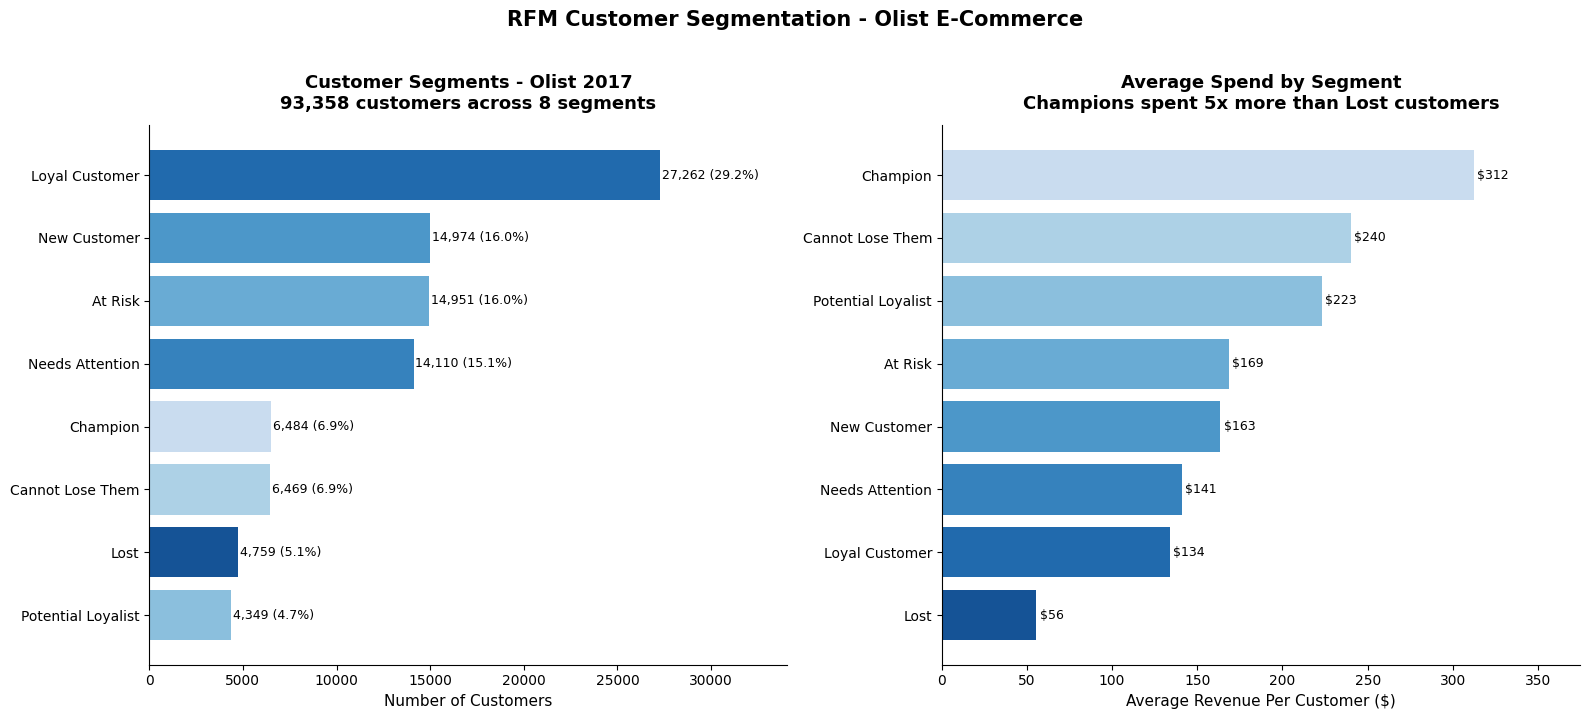

saved: rfm_segments.png


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

value_order = segment_summary.sort_values(
    'avg_monetary', ascending=True)['segment'].tolist()
blues = plt.cm.Blues(np.linspace(0.9, 0.25, 8))
color_map = {seg: blues[i] for i, seg in enumerate(value_order)}

# Chart 1: customer count
seg_plot = segment_summary.sort_values('customer_count')
axes[0].barh(seg_plot['segment'],
             seg_plot['customer_count'],
             color=[color_map[s] for s in seg_plot['segment']],
             alpha=0.95)
axes[0].set_title(
    'Customer Segments - Olist 2017\n'
    '93,358 customers across 8 segments',
    fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Number of Customers', fontsize=11)
for i, (val, pct) in enumerate(zip(seg_plot['customer_count'],
                                    seg_plot['pct_of_customers'])):
    axes[0].text(val + 100, i, f'{val:,} ({pct}%)',
                va='center', fontsize=9)
axes[0].set_xlim(0, seg_plot['customer_count'].max() * 1.25)
axes[0].spines[['top','right']].set_visible(False)

# Chart 2: avg spend
seg_money = segment_summary.sort_values('avg_monetary')
axes[1].barh(seg_money['segment'],
             seg_money['avg_monetary'],
             color=[color_map[s] for s in seg_money['segment']],
             alpha=0.95)
axes[1].set_title(
    'Average Spend by Segment\n'
    'Champions spent 5x more than Lost customers',
    fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Average Revenue Per Customer ($)', fontsize=11)
for i, val in enumerate(seg_money['avg_monetary']):
    axes[1].text(val + 2, i, f'${val:.0f}',
                va='center', fontsize=9)
axes[1].set_xlim(0, seg_money['avg_monetary'].max() * 1.2)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('RFM Customer Segmentation - Olist E-Commerce',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved: rfm_segments.png")

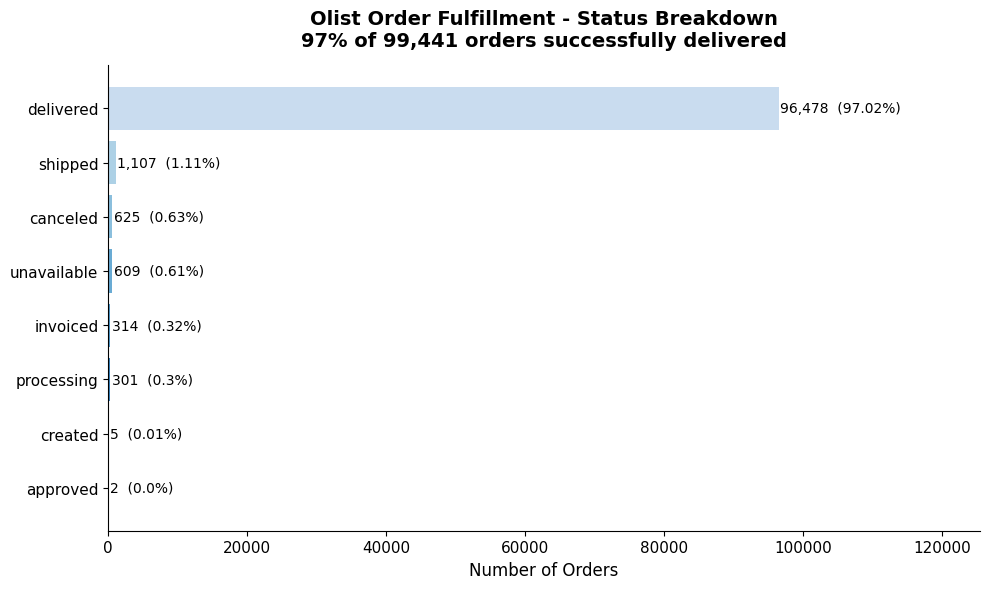

saved: order_fulfillment.png


In [41]:
status_counts = orders['order_status'].value_counts().reset_index()
status_counts.columns = ['status','count']
status_counts['pct'] = (
    status_counts['count'] / len(orders) * 100
).round(2)

fig, ax = plt.subplots(figsize=(10, 6))
blues_8 = plt.cm.Blues(np.linspace(0.9, 0.25, len(status_counts)))
status_plot = status_counts.sort_values('count')

ax.barh(status_plot['status'],
        status_plot['count'],
        color=blues_8, alpha=0.95)
ax.set_title(
    'Olist Order Fulfillment - Status Breakdown\n'
    '97% of 99,441 orders successfully delivered',
    fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Number of Orders', fontsize=12)
ax.tick_params(axis='both', labelsize=11)
for i, (val, pct) in enumerate(zip(status_plot['count'],
                                    status_plot['pct'])):
    ax.text(val + 200, i, f'{val:,}  ({pct}%)',
            va='center', fontsize=10)
ax.set_xlim(0, status_plot['count'].max() * 1.3)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('order_fulfillment.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved: order_fulfillment.png")

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils import resample

# delivery time
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date'])
orders['days_to_deliver'] = (
    orders['order_delivered_customer_date'] -
    orders['order_purchase_timestamp']
).dt.days

#aVg delivery per customer
rfm_orders = revenue_df.merge(
    orders[['order_id','days_to_deliver']],
    on='order_id', how='left')
delivery_avg = rfm_orders.groupby('customer_unique_id') \
                          ['days_to_deliver'].mean().reset_index()
delivery_avg.columns = ['customer_unique_id','avg_delivery_days']

model_df = rfm.merge(delivery_avg, on='customer_unique_id', how='left')
model_df['churned'] = (model_df['frequency'] == 1).astype(int)

# balance classes
features = ['recency','monetary','avg_delivery_days']
model_df_clean = model_df[features + ['churned']].dropna()

churned     = model_df_clean[model_df_clean['churned'] == 1]
not_churned = model_df_clean[model_df_clean['churned'] == 0]
churned_down = resample(churned, replace=False,
                         n_samples=len(not_churned), random_state=42)
balanced = pd.concat([churned_down, not_churned])

X = balanced[features]
y = balanced['churned']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(
    n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred,
      target_names=['Will Return','Will Churn']))
print("\nFeature Importance:")
for feat, imp in sorted(zip(features, model.feature_importances_),
                         key=lambda x: x[1], reverse=True):
    print(f"  {feat:25s} {imp:.3f}")

              precision    recall  f1-score   support

 Will Return       0.68      0.77      0.72       535
  Will Churn       0.76      0.66      0.71       586

    accuracy                           0.71      1121
   macro avg       0.72      0.72      0.71      1121
weighted avg       0.72      0.71      0.71      1121


Feature Importance:
  monetary                  0.788
  avg_delivery_days         0.116
  recency                   0.096


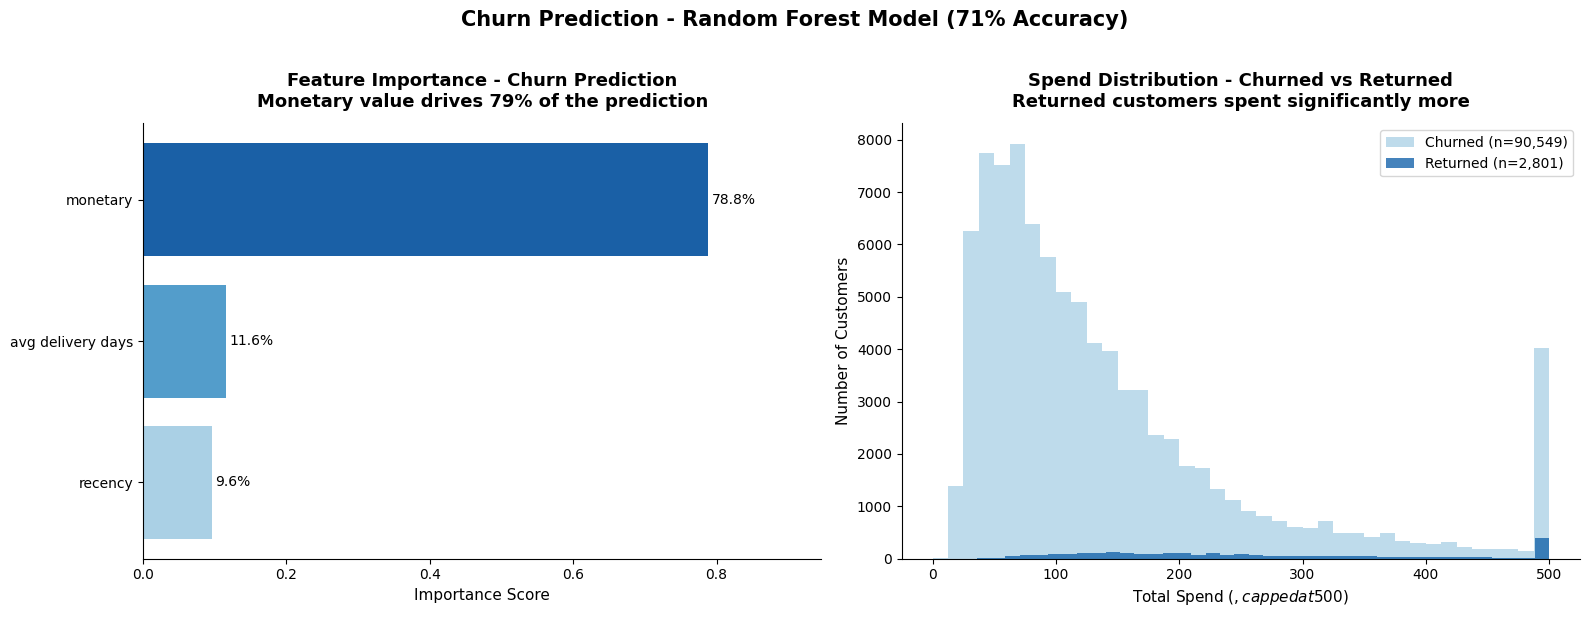

saved: churn_prediction.png


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: feature importance
features_sorted = sorted(zip(features, model.feature_importances_),
                          key=lambda x: x[1])
feat_names = [f[0].replace('_',' ') for f in features_sorted]
feat_vals  = [f[1] for f in features_sorted]

blues_3 = plt.cm.Blues(np.linspace(0.35, 0.85, 3))
axes[0].barh(feat_names, feat_vals, color=blues_3, alpha=0.95)
axes[0].set_title(
    'Feature Importance - Churn Prediction\n'
    'Monetary value drives 79% of the prediction',
    fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Importance Score', fontsize=11)
for i, val in enumerate(feat_vals):
    axes[0].text(val + 0.005, i, f'{val:.1%}',
                va='center', fontsize=10)
axes[0].set_xlim(0, max(feat_vals) * 1.2)
axes[0].spines[['top','right']].set_visible(False)

# Chart 2: spend distribution
returned  = model_df_clean[model_df_clean['churned']==0]['monetary']
churned_m = model_df_clean[model_df_clean['churned']==1]['monetary']
axes[1].hist(churned_m.clip(upper=500), bins=40,
             alpha=0.6, color=plt.cm.Blues(0.4),
             label=f'Churned (n={len(churned_m):,})')
axes[1].hist(returned.clip(upper=500), bins=40,
             alpha=0.8, color=plt.cm.Blues(0.8),
             label=f'Returned (n={len(returned):,})')
axes[1].set_title(
    'Spend Distribution - Churned vs Returned\n'
    'Returned customers spent significantly more',
    fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Total Spend ($, capped at $500)', fontsize=11)
axes[1].set_ylabel('Number of Customers', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Churn Prediction - Random Forest Model (71% Accuracy)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('churn_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved: churn_prediction.png")